# Fine-tuning on Pre-trained Model for Cell-type Annotation
In this tutorial, we demonstrate how to fine-tune a pre-trained model on a new dataset for the cell type annotation task. We use the Multiple Sclerosis dataset as an example and fine-tune on the pre-trained whole-body model. Please download the dataset folder from https://drive.google.com/drive/folders/1Qd42YNabzyr2pWt9xoY4cVMTAxsNBt4v?usp=sharing

We summarize the fine-tuning pipeline in the following steps, which can be used as a general recipe for finetuning on cell-type annotation tasks and beyond: 

     1. Specify hyper-parameter setup for integration task
     
     2. Load and pre-process data
     
     3. Load the pre-trained scGPT model
     
     4. Finetune scGPT with task-specific objectives
     
     5. Evaluate fine-tuned scGPT

## Step 0: Load and install packages

In [1]:
# Try: Remove SelfGraphConv (check in unified_preproc)

In [2]:
# %%
import copy
import gc
import json
import os
from pathlib import Path
import shutil
import sys
import time
import traceback
from typing import List, Tuple, Dict, Union, Optional
import warnings
import pandas as pd
# from . import asyn
import pickle
import torch
from anndata import AnnData
import scanpy as sc
# import scvi
import seaborn as sns
import numpy as np
import wandb
from scipy.sparse import issparse
import matplotlib.pyplot as plt
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from torchtext.vocab import Vocab
from torchtext._torchtext import (
    Vocab as VocabPybind,
)
from sklearn.metrics import confusion_matrix

sys.path.insert(0, "../")
import scgpt as scg
from scgpt.model import TransformerModel, AdversarialDiscriminator
from scgpt.tokenizer import tokenize_and_pad_batch, random_mask_value
from scgpt.loss import (
    masked_mse_loss,
    masked_relative_error,
    criterion_neg_log_bernoulli,
)
from scgpt.tokenizer.gene_tokenizer import GeneVocab
from scgpt.preprocess import Preprocessor
from scgpt import SubsetsBatchSampler
from scgpt.utils import set_seed, category_str2int, eval_scib_metrics

sc.set_figure_params(figsize=(6, 6))
os.environ["KMP_WARNINGS"] = "off"
warnings.filterwarnings('ignore')

/home/atuin/v138da/v138da11/software/private/conda/envs/gpt/lib/python3.9/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/home/atuin/v138da/v138da11/software/private/conda/envs/gpt/lib/python3.9/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/home/atuin/v138da/v138da11/software/private/conda/envs/gpt/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# !which python
# !pip install torchtext

In [4]:
# !pip install scgpt "torch<=2.2.2" "numpy<2" "umap-learn<0.5.7"
# # !pip install wandb louvain
# # !pip install lightgbm
# !pip install scgpt "flash-attn<1.0.5"  # optional, recommended (bo cai nay): chi cai pip install scgpt
# !pip install "torch<=2.2.2" torchvision torchaudio
# !pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.2.0+cu121.html
# !pip install torch_geometric
# !pip install nbformat
# !pip install scanpy==1.10.2
## Restate kernel after installation

In [5]:
# !pip install -q -U gdown
# import gdown
# gdown.download_folder(
#     "https://drive.google.com/drive/folders/1oWh_-ZRdhtoGQ2Fw24HP41FgLoomVo-y",
#     output='/home/tttoan_hoandv/research/scGPT/models/scGPT_human',
# )
# gdown.download_folder(
#     "https://drive.google.com/drive/folders/1hZLz8aEsv5_VeTt8LtrvZ66fLFWp0fMP?usp=sharing",
#     output='/home/tttoan_hoandv/research/scGPT/data',
# )
# gdown.download_folder(
#     "https://drive.google.com/drive/folders/13QzLHilYUd0v3HTwa_9n4G4yEF-hdkqa?usp=sharing",
#     output='/home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/models/pan-cancer',
# )

In [6]:
from scipy.spatial import cKDTree
from scipy.stats import mode
from collections import Counter
def convert_gene_adata(adata, mapping):
    overlap = [g for g in adata.var_names if g in mapping]
    if len(overlap) < 1:
        adata.var_names_make_unique()
        return (adata)

    adata.var.index = adata.var.index.map(mapping)
    adata = adata[:, adata.var.index.notnull()].copy()
    adata.var_names_make_unique()
    return (adata)
    
def cKD_refine_label(coords, labels, k):
    # Step 1: Build KD-Tree
    tree = cKDTree(coords.copy())

    # Step 2: Find k-nearest neighbors for each spot
    # k+1 because the closest point is itself
    distances, neighbors = tree.query(coords, k=k+1)

    # Exclude self-neighbor (first column)
    neighbors = neighbors[:, 1:]

    # Step 3: Reassign labels
    new_labels = labels.copy()
    for i, nbrs in enumerate(neighbors):
        # Get the labels of neighboring spots
        neighbor_labels = labels[nbrs]
        # Find the most common label among neighbors
        # most_common_label = mode(neighbor_labels).mode[0]
        most_common_label = Counter(neighbor_labels).most_common(1)[0][0]
        # Reassign the label
        new_labels[i] = most_common_label
    return (new_labels)

_label_color_map = {}
def make_plot(adata, key, w=6.6, d=3.5):
    global _label_color_map
    
    df_spatial = pd.DataFrame(adata.obsm['spatial'], columns=['x', 'y'])
    df_spatial['region'] = list(adata.obs[key])
    df_spatial['region'] = df_spatial['region'].astype(str)
    # df_spatial['region'] = adata.obs[key].astype(str)
    
    unique_labels = df_spatial['region'].unique()
    
    plt.figure(figsize=(w, d))
    
    if not _label_color_map:  
        # First time — simple plot
        sns.scatterplot(
            x="x", y="y", hue="region",
            data=df_spatial, palette="tab10", s=20
        )
        # Save the assigned colors
        handles, labels = plt.gca().get_legend_handles_labels()
        palette_dict = dict(zip(labels, sns.color_palette("tab10", len(labels))))
        _label_color_map.update(palette_dict)
    else:
        # Reuse existing colors, assign new ones if needed
        palette = sns.color_palette("tab10")
        for label in unique_labels:
            if label not in _label_color_map:
                _label_color_map[label] = palette[len(_label_color_map) % len(palette)]
        sns.scatterplot(
            x="x", y="y", hue="region",
            data=df_spatial,
            palette={lbl: _label_color_map[lbl] for lbl in unique_labels},
            s=20
        )
    
    plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

## Step 1: Specify hyper-parameter setup for cell-type annotation task
Listed below are some hyper-parameter recommendations for the cell-type task. Note that the CLS objective is on to facilitate cell-type classification.

In [7]:
hyperparameter_defaults = dict(
    seed=126,
    dataset_name="ms",
    do_train=True,
    load_model="/home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/models/scGPT_human",
    # load_model= '/home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/models/pan-cancer',
    mask_ratio=0.0,
    epochs=40, #20
    n_bins=51, # 51
    MVC=False, # Masked value prediction for cell embedding
    ecs_thres=0.0, # Elastic cell similarity objective, 0.0 to 1.0, 0.0 to disable
    dab_weight=0.0,
    lr=1e-4, # 1e-4
    batch_size=16, #32
    layer_size=128, # 128
    nlayers=4,  # number of nn.TransformerEncoderLayer in nn.TransformerEncoder
    nhead=4,  # number of heads in nn.MultiheadAttention
    dropout=0.2,  # dropout probability 0.2
    schedule_ratio=0.95,  # ratio of epochs for learning rate schedule # default 0.90
    save_eval_interval=5,
    fast_transformer=True,
    pre_norm=False,
    amp=True,  # Automatic Mixed Precision
    include_zero_gene = False,
    freeze = True, #freeze: False
    DSBN = False,  # Domain-spec batchnorm
)
# print('Switch the learning rate back to 1e-4')

In [8]:
# key: eae607e6e500c13c75854f5b95b9a488c9934aa6

In [9]:
import os
os.environ["WANDB_MODE"] = "offline"  # Force offline mode
import wandb
run = wandb.init(
    config=hyperparameter_defaults,
    project="scGPT",
    reinit=True,
    name="finetune-scgpt-run1",
    settings=wandb.Settings(start_method="fork"),
)
config = wandb.config
print(config)

wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


{'seed': 126, 'dataset_name': 'ms', 'do_train': True, 'load_model': '/home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/models/scGPT_human', 'mask_ratio': 0, 'epochs': 40, 'n_bins': 51, 'MVC': False, 'ecs_thres': 0, 'dab_weight': 0, 'lr': 0.0001, 'batch_size': 16, 'layer_size': 128, 'nlayers': 4, 'nhead': 4, 'dropout': 0.2, 'schedule_ratio': 0.95, 'save_eval_interval': 5, 'fast_transformer': True, 'pre_norm': False, 'amp': True, 'include_zero_gene': False, 'freeze': True, 'DSBN': False}


In [10]:
# settings for input and preprocessing
pad_token = "<pad>"
special_tokens = [pad_token, "<cls>", "<eoc>"]
mask_ratio = config.mask_ratio
mask_value = "auto"  # for masked values, now it should always be auto

include_zero_gene = config.include_zero_gene  # if True, include zero genes among hvgs in the training
max_seq_len = 3001
n_bins = config.n_bins

# input/output representation
input_style = "binned"  # "normed_raw", "log1p", or "binned"
output_style = "binned"  # "normed_raw", "log1p", or "binned"

# settings for training
MLM = False  # whether to use masked language modeling, currently it is always on.
CLS = True  # celltype classification objective
ADV = False  # Adversarial training for batch correction
CCE = False  # Contrastive cell embedding objective
MVC = config.MVC  # Masked value prediction for cell embedding
ECS = config.ecs_thres > 0  # Elastic cell similarity objective
DAB = False  # Domain adaptation by reverse backpropagation, set to 2 for separate optimizer
INPUT_BATCH_LABELS = False  # TODO: have these help MLM and MVC, while not to classifier
input_emb_style = "continuous"  # "category" or "continuous" or "scaling"
cell_emb_style = "cls"  # "avg-pool" or "w-pool" or "cls"
adv_E_delay_epochs = 0  # delay adversarial training on encoder for a few epochs
adv_D_delay_epochs = 0
mvc_decoder_style = "inner product"
ecs_threshold = config.ecs_thres
dab_weight = config.dab_weight

explicit_zero_prob = MLM and include_zero_gene  # whether explicit bernoulli for zeros
do_sample_in_train = False and explicit_zero_prob  # sample the bernoulli in training

per_seq_batch_sample = False

# settings for optimizer
lr = config.lr  # TODO: test learning rate ratio between two tasks
lr_ADV = 1e-3  # learning rate for discriminator, used when ADV is True
batch_size = config.batch_size
eval_batch_size = config.batch_size
epochs = config.epochs
schedule_interval = 1

# settings for the model
fast_transformer = config.fast_transformer
fast_transformer_backend = "flash"  # "linear" or "flash"
embsize = config.layer_size  # embedding dimension
d_hid = config.layer_size  # dimension of the feedforward network in TransformerEncoder
nlayers = config.nlayers  # number of TransformerEncoderLayer in TransformerEncoder
nhead = config.nhead  # number of heads in nn.MultiheadAttention
dropout = config.dropout  # dropout probability

# logging
log_interval = 100  # iterations
save_eval_interval = config.save_eval_interval  # epochs
do_eval_scib_metrics = True

In [11]:
# %% validate settings
assert input_style in ["normed_raw", "log1p", "binned"]
assert output_style in ["normed_raw", "log1p", "binned"]
assert input_emb_style in ["category", "continuous", "scaling"]
if input_style == "binned":
    if input_emb_style == "scaling":
        raise ValueError("input_emb_style `scaling` is not supported for binned input.")
elif input_style == "log1p" or input_style == "normed_raw":
    if input_emb_style == "category":
        raise ValueError(
            "input_emb_style `category` is not supported for log1p or normed_raw input."
        )

if input_emb_style == "category":
    mask_value = n_bins + 1
    pad_value = n_bins  # for padding gene expr values
    n_input_bins = n_bins + 2
else:
    mask_value = -1
    pad_value = -2
    n_input_bins = n_bins

if ADV and DAB:
    raise ValueError("ADV and DAB cannot be both True.")
DAB_separate_optim = True if DAB > 1 else False

In [12]:
dataset_name = config.dataset_name
save_dir = Path(f"/home/hpc/v138da/v138da11/scGPTfinetune/scGPT/models/dev_{dataset_name}-{time.strftime('%b%d-%H-%M')}/")
save_dir.mkdir(parents=True, exist_ok=True)
print(f"save to {save_dir}")
logger = scg.logger
scg.utils.add_file_handler(logger, save_dir / "run.log")

save to /home/hpc/v138da/v138da11/scGPTfinetune/scGPT/models/dev_ms-Sep09-19-49


In [13]:
# break;

## Step 2: Load and pre-process data
We follow the standard scGPT data pre-processing pipelines for the cell-type annotation task. Note that since now we have two datasets at hand (i.e., reference and query data), the same pre-prpocessing steps need to be applied to both of them.

In [14]:
from sklearn.neighbors import kneighbors_graph
def SelfGraphConv(adata, n_neighbors = 3):
    connectivity = kneighbors_graph(adata.obsm['spatial'], n_neighbors=n_neighbors, include_self=False)
    connectivity = 0.5 * (connectivity + connectivity.T)
    adata.X = connectivity.dot(adata.X)
    return (adata)

In [15]:
# train, test pair
pair_data_dir = [
['/home/vault/v138da/v138da11/data/NicheCompass/analysis/nanostring_cosmx_human_nsclc_1krepresentative.h5ad',
'/home/vault/v138da/v138da11/data/NicheCompass/analysis/nanostring_cosmx_human_nsclc_lung6_v2.h5ad',], 
]

In [16]:
def unified_preproc(adata, mapping, annotation_key):
    adata = SelfGraphConv(adata, n_neighbors = 5)
    # annotation_key = 'scNiche' #annotations_level_0
    if annotation_key in adata.obs:
        if annotation_key is not 'Region':
            adata.obs['Region'] = list(adata.obs[annotation_key])
        adata = adata[~adata.obs.Region.isna()].copy()
    
    adata = convert_gene_adata(adata, mapping)
    adata.var['gene_name'] = adata.var_names
    if annotation_key in adata.obs:
        adata.obs["celltype"] = adata.obs["Region"].astype("category")
    adata.var.set_index(adata.var["gene_name"], inplace=True)
    return adata

def test_preproc(adata_train, adata_test, mapping, annotation_key):
    adata_test_origin = unified_preproc(adata_test, mapping, annotation_key)
    
    # Convert to DataFrame for reindexing
    test_df = pd.DataFrame(
        adata_test_origin.X.toarray() if hasattr(adata_test_origin.X, "toarray") else adata_test_origin.X,
        columns=adata_test_origin.var_names,
        index=adata_test_origin.obs_names
    )
    selected_genes = list(adata_train.var_names)
    test_df = test_df.reindex(columns=selected_genes, fill_value=0)
    adata_test = AnnData(X=test_df.values)
    # adata_test.obs['Region'] = list(adata_test_origin.obs['Region'])
    adata_test.obsm['spatial'] = adata_test_origin.obsm['spatial']
    adata_test.var_names = selected_genes
    adata_test.var['gene_name'] = adata_test.var_names
    return adata_test

In [17]:
# import mygene
# mg = mygene.MyGeneInfo()
# ensembl_ids = adata.var.index.tolist()
# out = mg.querymany(
#     ensembl_ids,
#     scopes="ensembl.gene",
#     fields="symbol",
#     species="human"
# )
# mapping = {item['query']: item.get('symbol', item['query']) for item in out}
# import json
# Save mapping to JSON
# with open("/home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/data/ensembl_to_hgnc.json", "w") as f:
#     json.dump(mapping, f, indent=2)
# load
#with open("/home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/data/ensembl_to_hgnc.json") as f:
with open("/home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/data/ensembl_to_hgnc_v2.json") as f: #danalysis_STdata
    mapping = json.load(f)

In [18]:
# Data is here: https://drive.google.com/drive/folders/1kxSSaSVZwddADUtbOgLQs8f9iNEZjxqz

In [19]:
import anndata as ad, pandas as pd, numpy as np
# train_ids = ['A1', 'B1', 'C1']
# # train_data_idx = train_ids[0] # 151507 151669 151673 
# train_adata_list = []
# for train_id in train_ids:
#     adata1 = sc.read('/home/vault/v138da/v138da11/data/Andrews/'+train_id+'_filter.h5ad')
#     adata1 = adata1[~adata1.obs.Region.isna()].copy()
#     adata1.var['gene_name'] = adata1.var_names
#     adata1 = SelfGraphConv(adata1, n_neighbors = 3)
#     train_adata_list.append(adata1)
# adata = ad.concat(train_adata_list)

annotation_key = 'niche' #'scNiche'
selected_pair_idx = -1
# adata = sc.read(pair_data_dir[selected_pair_idx][0])

adata = sc.read_visium('/home/vault/v138da/v138da11/data/DeepGFT/V1_Breast_Cancer_Block_A_Section_1', count_file='filtered_feature_bc_matrix.h5')
ground_truth = pd.read_csv('/home/vault/v138da/v138da11/data/DeepGFT/V1_Breast_Cancer_Block_A_Section_1/metadata.tsv', delimiter='\t', index_col=0)
adata.obs['niche'] = ground_truth['ground_truth']

In [20]:
adata = unified_preproc(adata, mapping, annotation_key)

In [21]:
test_data_idx = '1160920F'
# adata_test = sc.read('/home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/data/151508.h5ad')
# adata_test_origin = sc.read('/home/vault/v138da/v138da11/data/Wu/CID44971_filter.h5ad') 
# print(pair_data_dir[selected_pair_idx][1])
# adata_test_origin = sc.read(pair_data_dir[selected_pair_idx][1]) 
adata_test_origin = sc.read_visium('/home/vault/v138da/v138da11/data/DeepGFT/V1_Breast_Cancer_Block_A_Section_2', count_file='filtered_feature_bc_matrix.h5')

adata_test = test_preproc(adata, adata_test_origin, mapping, annotation_key)

In [22]:
from utils import plot_2D
# plot_2D(adata, adata.obs['niche'])

In [23]:
adata

AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'niche', 'Region', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'gene_name'
    uns: 'spatial'
    obsm: 'spatial'

In [24]:
adata_test

AnnData object with n_obs × n_vars = 3987 × 36601
    var: 'gene_name'
    obsm: 'spatial'

In [25]:
# adata_test.var['gene_name'] = adata_test.var_names
# adata_test = SelfGraphConv(adata_test, n_neighbors = 3)
n_hvg_genes = 1000
adata.var['gene_name'] = adata.var_names
sc.pp.highly_variable_genes(adata, n_top_genes=n_hvg_genes, flavor='seurat_v3')
hvg_mask = adata.var['highly_variable']
hvg_genes = adata.var_names[hvg_mask]
adata = adata[:, hvg_genes]
adata_test = adata_test[:, hvg_genes]

adata.obs["batch_id"]  = adata.obs["str_batch"] = "0"
adata_test.obs["batch_id"]  = adata_test.obs["str_batch"] = "1"          
data_is_raw = False
filter_gene_by_counts = False
adata = adata.concatenate(adata_test, batch_key="str_batch")
                
# make the batch category column
batch_id_labels = adata.obs["str_batch"].astype("category").cat.codes.values
adata.obs["batch_id"] = batch_id_labels
celltype_id_labels = adata.obs["celltype"].astype("category").cat.codes.values
celltypes = adata.obs["celltype"].unique()
num_types = len(np.unique(celltype_id_labels))
id2type = dict(enumerate(adata.obs["celltype"].astype("category").cat.categories))

################################# TODO ##################################
train_labels = np.array(list(adata.obs["celltype"]))
all_labels = np.unique(train_labels)
all_labels_sorted = np.sort(all_labels)
label_to_id = {label: i for i, label in enumerate(all_labels_sorted)}
all_labels_int = np.array([label_to_id[l] for l in train_labels])
adata.obs["celltype_id"]  = all_labels_int

# adata.obs["celltype_id"] = celltype_id_labels
adata.var["gene_name"] = adata.var.index.tolist()

In [26]:
adata.shape, adata_test.shape

((7785, 1000), (3987, 1000))

In [27]:
if config.load_model is not None:
    model_dir = Path(config.load_model)
    model_config_file = model_dir / "args.json"
    model_file = model_dir / "best_model.pt"
    vocab_file = model_dir / "vocab.json"

    vocab = GeneVocab.from_file(vocab_file)
    shutil.copy(vocab_file, save_dir / "vocab.json")
    for s in special_tokens:
        if s not in vocab:
            vocab.append_token(s)

    adata.var["id_in_vocab"] = [
        1 if gene in vocab else -1 for gene in adata.var["gene_name"]
    ]
    gene_ids_in_vocab = np.array(adata.var["id_in_vocab"])
    logger.info(
        f"match {np.sum(gene_ids_in_vocab >= 0)}/{len(gene_ids_in_vocab)} genes "
        f"in vocabulary of size {len(vocab)}."
    )
    adata = adata[:, adata.var["id_in_vocab"] >= 0]

    # model
    with open(model_config_file, "r") as f:
        model_configs = json.load(f)
    logger.info(
        f"Resume model from {model_file}, the model args will override the "
        f"config {model_config_file}."
    )
    embsize = model_configs["embsize"]
    nhead = model_configs["nheads"]
    d_hid = model_configs["d_hid"]
    nlayers = model_configs["nlayers"]
    n_layers_cls = model_configs["n_layers_cls"]

scGPT - INFO - match 920/1000 genes in vocabulary of size 60697.
scGPT - INFO - Resume model from /home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/models/scGPT_human/best_model.pt, the model args will override the config /home/hpc/v138da/v138da11/scGPTfinetune/scGPT2/models/scGPT_human/args.json.


In [28]:
# adata.X = adata.X - adata.X.min()

In [29]:
test_labels = np.array(list(adata.obs["Region"]))
all_labels = np.unique(test_labels)
all_labels_sorted = np.sort(all_labels)
labels_dict = {label: i for i, label in enumerate(all_labels_sorted)}
inv_labels_dict = {i: label for label, i in labels_dict.items()}

In [30]:
# set(test_labels)

In [31]:
# set up the preprocessor, use the args to config the workflow
data_is_raw = False
preprocessor = Preprocessor(
    use_key="X",  # the key in adata.layers to use as raw data
    # filter_gene_by_counts=filter_gene_by_counts,  # step 1
    filter_cell_by_counts=False,  # step 2
    normalize_total=1e4,  # 3. whether to normalize the raw data and to what sum
    result_normed_key="X_normed",  # the key in adata.layers to store the normalized data
    log1p=data_is_raw,  # 4. whether to log1p the normalized data
    result_log1p_key="X_log1p",
    subset_hvg=False,  # 5. whether to subset the raw data to highly variable genes
    hvg_flavor="seurat_v3" if data_is_raw else "cell_ranger",
    binning=n_bins,  # 6. whether to bin the raw data and to what number of bins
    result_binned_key="X_binned",  # the key in adata.layers to store the binned data
)

adata_test = adata[adata.obs["str_batch"] == "1"]
adata = adata[adata.obs["str_batch"] == "0"]

preprocessor(adata, batch_key=None)
preprocessor(adata_test, batch_key=None)

scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Binning data ...


In [32]:
input_layer_key = {  # the values of this map coorespond to the keys in preprocessing
    "normed_raw": "X_normed",
    "log1p": "X_normed",
    "binned": "X_binned",
}[input_style]
all_counts = (
    adata.layers[input_layer_key].toarray()
    if issparse(adata.layers[input_layer_key])
    else adata.layers[input_layer_key]
)
genes = adata.var["gene_name"].tolist()

celltypes_labels = adata.obs["celltype_id"].tolist()  # make sure count from 0
celltypes_labels = np.array(celltypes_labels)

batch_ids = adata.obs["batch_id"].tolist()
num_batch_types = len(set(batch_ids))
batch_ids = np.array(batch_ids)

(
    train_data,
    valid_data,
    train_celltype_labels,
    valid_celltype_labels,
    train_batch_labels,
    valid_batch_labels,
) = train_test_split(
    all_counts, celltypes_labels, batch_ids, test_size=0.1, shuffle=True
)

In [33]:
if config.load_model is None:
    vocab = Vocab(
        VocabPybind(genes + special_tokens, None)
    )  # bidirectional lookup [gene <-> int]
vocab.set_default_index(vocab["<pad>"])
gene_ids = np.array(vocab(genes), dtype=int)

In [34]:
tokenized_train = tokenize_and_pad_batch(
    train_data,
    gene_ids,
    max_len=max_seq_len,
    vocab=vocab,
    pad_token=pad_token,
    pad_value=pad_value,
    append_cls=True,  # append <cls> token at the beginning
    include_zero_gene=include_zero_gene,
)
tokenized_valid = tokenize_and_pad_batch(
    valid_data,
    gene_ids,
    max_len=max_seq_len,
    vocab=vocab,
    pad_token=pad_token,
    pad_value=pad_value,
    append_cls=True,
    include_zero_gene=include_zero_gene,
)
logger.info(
    f"train set number of samples: {tokenized_train['genes'].shape[0]}, "
    f"\n\t feature length: {tokenized_train['genes'].shape[1]}"
)
logger.info(
    f"valid set number of samples: {tokenized_valid['genes'].shape[0]}, "
    f"\n\t feature length: {tokenized_valid['genes'].shape[1]}"
)

scGPT - INFO - train set number of samples: 3418, 
	 feature length: 718
scGPT - INFO - valid set number of samples: 380, 
	 feature length: 696


In [35]:
def prepare_data(sort_seq_batch=False) -> Tuple[Dict[str, torch.Tensor]]:
    masked_values_train = random_mask_value(
        tokenized_train["values"],
        mask_ratio=mask_ratio,
        mask_value=mask_value,
        pad_value=pad_value,
    )
    masked_values_valid = random_mask_value(
        tokenized_valid["values"],
        mask_ratio=mask_ratio,
        mask_value=mask_value,
        pad_value=pad_value,
    )
    print(
        f"random masking at epoch {epoch:3d}, ratio of masked values in train: ",
        f"{(masked_values_train == mask_value).sum() / (masked_values_train - pad_value).count_nonzero():.4f}",
    )

    input_gene_ids_train, input_gene_ids_valid = (
        tokenized_train["genes"],
        tokenized_valid["genes"],
    )
    input_values_train, input_values_valid = masked_values_train, masked_values_valid
    target_values_train, target_values_valid = (
        tokenized_train["values"],
        tokenized_valid["values"],
    )

    tensor_batch_labels_train = torch.from_numpy(train_batch_labels).long()
    tensor_batch_labels_valid = torch.from_numpy(valid_batch_labels).long()

    tensor_celltype_labels_train = torch.from_numpy(train_celltype_labels).long()
    tensor_celltype_labels_valid = torch.from_numpy(valid_celltype_labels).long()

    if sort_seq_batch:  # TODO: update to random pick seq source in each traning batch
        train_sort_ids = np.argsort(train_batch_labels)
        input_gene_ids_train = input_gene_ids_train[train_sort_ids]
        input_values_train = input_values_train[train_sort_ids]
        target_values_train = target_values_train[train_sort_ids]
        tensor_batch_labels_train = tensor_batch_labels_train[train_sort_ids]
        tensor_celltype_labels_train = tensor_celltype_labels_train[train_sort_ids]

        valid_sort_ids = np.argsort(valid_batch_labels)
        input_gene_ids_valid = input_gene_ids_valid[valid_sort_ids]
        input_values_valid = input_values_valid[valid_sort_ids]
        target_values_valid = target_values_valid[valid_sort_ids]
        tensor_batch_labels_valid = tensor_batch_labels_valid[valid_sort_ids]
        tensor_celltype_labels_valid = tensor_celltype_labels_valid[valid_sort_ids]

    train_data_pt = {
        "gene_ids": input_gene_ids_train,
        "values": input_values_train,
        "target_values": target_values_train,
        "batch_labels": tensor_batch_labels_train,
        "celltype_labels": tensor_celltype_labels_train,
    }
    valid_data_pt = {
        "gene_ids": input_gene_ids_valid,
        "values": input_values_valid,
        "target_values": target_values_valid,
        "batch_labels": tensor_batch_labels_valid,
        "celltype_labels": tensor_celltype_labels_valid,
    }

    return train_data_pt, valid_data_pt


# dataset
class SeqDataset(Dataset):
    def __init__(self, data: Dict[str, torch.Tensor]):
        self.data = data

    def __len__(self):
        return self.data["gene_ids"].shape[0]

    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.data.items()}


# data_loader
def prepare_dataloader(
    data_pt: Dict[str, torch.Tensor],
    batch_size: int,
    shuffle: bool = False,
    intra_domain_shuffle: bool = False,
    drop_last: bool = False,
    num_workers: int = 0,
) -> DataLoader:
    if num_workers == 0:
        num_workers = min(len(os.sched_getaffinity(0)), batch_size // 2)

    dataset = SeqDataset(data_pt)

    if per_seq_batch_sample:
        # find the indices of samples in each seq batch
        subsets = []
        batch_labels_array = data_pt["batch_labels"].numpy()
        for batch_label in np.unique(batch_labels_array):
            batch_indices = np.where(batch_labels_array == batch_label)[0].tolist()
            subsets.append(batch_indices)
        data_loader = DataLoader(
            dataset=dataset,
            batch_sampler=SubsetsBatchSampler(
                subsets,
                batch_size,
                intra_subset_shuffle=intra_domain_shuffle,
                inter_subset_shuffle=shuffle,
                drop_last=drop_last,
            ),
            num_workers=num_workers,
            pin_memory=True,
        )
        return data_loader

    data_loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
    )
    return data_loader


## Step 3: Load the pre-trained scGPT model

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ntokens = len(vocab)  # size of vocabulary
model = TransformerModel(
    ntokens,
    embsize,
    nhead,
    d_hid,
    nlayers,
    nlayers_cls=3,
    n_cls=num_types if CLS else 1,
    vocab=vocab,
    dropout=dropout,
    pad_token=pad_token,
    pad_value=pad_value,
    do_mvc=MVC,
    do_dab=DAB,
    use_batch_labels=INPUT_BATCH_LABELS,
    num_batch_labels=num_batch_types,
    domain_spec_batchnorm=config.DSBN,
    input_emb_style=input_emb_style,
    n_input_bins=n_input_bins,
    cell_emb_style=cell_emb_style,
    mvc_decoder_style=mvc_decoder_style,
    ecs_threshold=ecs_threshold,
    explicit_zero_prob=explicit_zero_prob,
    use_fast_transformer=fast_transformer,
    fast_transformer_backend=fast_transformer_backend,
    pre_norm=config.pre_norm,
)
if config.load_model is not None:
    try:
        model.load_state_dict(torch.load(model_file))
        # logger.info(f"Loading all model params from {model_file}")
    except:
        # only load params that are in the model and match the size
        model_dict = model.state_dict()
        pretrained_dict = torch.load(model_file)
        pretrained_dict = {
            k: v
            for k, v in pretrained_dict.items()
            if k in model_dict and v.shape == model_dict[k].shape
        }
        # for k, v in pretrained_dict.items():
        #     logger.info(f"Loading params {k} with shape {v.shape}")
        model_dict.update(pretrained_dict)
        model.load_state_dict(model_dict)

pre_freeze_param_count = sum(dict((p.data_ptr(), p.numel()) for p in model.parameters() if p.requires_grad).values())

# Freeze all pre-decoder weights
for name, para in model.named_parameters():
    # print("-"*20)
    # print(f"name: {name}")
    if config.freeze and "encoder" in name and "transformer_encoder" not in name:
    # if config.freeze and "encoder" in name:
        # print(f"freezing weights for: {name}")
        para.requires_grad = False

post_freeze_param_count = sum(dict((p.data_ptr(), p.numel()) for p in model.parameters() if p.requires_grad).values())

logger.info(f"Total Pre freeze Params {(pre_freeze_param_count )}")
logger.info(f"Total Post freeze Params {(post_freeze_param_count )}")
wandb.log(
        {
            "info/pre_freeze_param_count": pre_freeze_param_count,
            "info/post_freeze_param_count": post_freeze_param_count,
        },
)

model.to(device)
wandb.watch(model)

if ADV:
    discriminator = AdversarialDiscriminator(
        d_model=embsize,
        n_cls=num_batch_types,
    ).to(device)

scGPT - INFO - Total Pre freeze Params 51342358
scGPT - INFO - Total Post freeze Params 19999766


In [37]:
device

device(type='cuda')

In [38]:
criterion = masked_mse_loss
criterion_cls = nn.CrossEntropyLoss()
criterion_dab = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=lr, eps=1e-4 if config.amp else 1e-8
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, schedule_interval, gamma=config.schedule_ratio
)
if DAB_separate_optim:
    optimizer_dab = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler_dab = torch.optim.lr_scheduler.StepLR(
        optimizer_dab, schedule_interval, gamma=config.schedule_ratio
    )
if ADV:
    criterion_adv = nn.CrossEntropyLoss()  # consider using label smoothing
    optimizer_E = torch.optim.Adam(model.parameters(), lr=lr_ADV)
    scheduler_E = torch.optim.lr_scheduler.StepLR(
        optimizer_E, schedule_interval, gamma=config.schedule_ratio
    )
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_ADV)
    scheduler_D = torch.optim.lr_scheduler.StepLR(
        optimizer_D, schedule_interval, gamma=config.schedule_ratio
    )

scaler = torch.cuda.amp.GradScaler(enabled=config.amp)

In [39]:
def train(model: nn.Module, loader: DataLoader) -> None:
    """
    Train the model for one epoch.
    """
    model.train()
    (
        total_loss,
        total_mse,
        total_cls,
        total_cce,
        total_mvc,
        total_ecs,
        total_dab,
        total_adv_E,
        total_adv_D,
        total_zero_log_prob,
        total_mvc_zero_log_prob,
    ) = (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
    total_error = 0.0
    start_time = time.time()

    num_batches = len(loader)
    for batch, batch_data in enumerate(loader):
        input_gene_ids = batch_data["gene_ids"].to(device)
        input_values = batch_data["values"].to(device)
        target_values = batch_data["target_values"].to(device)
        batch_labels = batch_data["batch_labels"].to(device)
        celltype_labels = batch_data["celltype_labels"].to(device)

        src_key_padding_mask = input_gene_ids.eq(vocab[pad_token])
        with torch.cuda.amp.autocast(enabled=config.amp):
            output_dict = model(
                input_gene_ids,
                input_values,
                src_key_padding_mask=src_key_padding_mask,
                batch_labels=batch_labels if INPUT_BATCH_LABELS or config.DSBN else None,
                CLS=CLS,
                CCE=CCE,
                MVC=MVC,
                ECS=ECS,
                do_sample=do_sample_in_train,
                #generative_training=False
            )

            masked_positions = input_values.eq(mask_value)  # the postions to predict
            loss = 0.0
            metrics_to_log = {}
            if MLM:
                loss_mse = criterion(
                    output_dict["mlm_output"], target_values, masked_positions
                )
                loss = loss + loss_mse
                metrics_to_log = {"train/mse": loss_mse.item()}
            if explicit_zero_prob:
                loss_zero_log_prob = criterion_neg_log_bernoulli(
                    output_dict["mlm_zero_probs"], target_values, masked_positions
                )
                loss = loss + loss_zero_log_prob
                metrics_to_log.update({"train/nzlp": loss_zero_log_prob.item()})
            if CLS:
                loss_cls = criterion_cls(output_dict["cls_output"], celltype_labels)
                loss = loss + loss_cls
                metrics_to_log.update({"train/cls": loss_cls.item()})

                error_rate = 1 - (
                    (output_dict["cls_output"].argmax(1) == celltype_labels)
                    .sum()
                    .item()
                ) / celltype_labels.size(0)
            if CCE:
                loss_cce = 10 * output_dict["loss_cce"]
                loss = loss + loss_cce
                metrics_to_log.update({"train/cce": loss_cce.item()})
            if MVC:
                loss_mvc = criterion(
                    output_dict["mvc_output"], target_values, masked_positions
                )
                loss = loss + loss_mvc
                metrics_to_log.update({"train/mvc": loss_mvc.item()})
            if MVC and explicit_zero_prob:
                loss_mvc_zero_log_prob = criterion_neg_log_bernoulli(
                    output_dict["mvc_zero_probs"], target_values, masked_positions
                )
                loss = loss + loss_mvc_zero_log_prob
                metrics_to_log.update({"train/mvc_nzlp": loss_mvc_zero_log_prob.item()})
            if ECS:
                loss_ecs = 10 * output_dict["loss_ecs"]
                loss = loss + loss_ecs
                metrics_to_log.update({"train/ecs": loss_ecs.item()})
            if DAB:
                # try weighting and separate optimizer
                loss_dab = criterion_dab(output_dict["dab_output"], batch_labels)
                loss = loss + dab_weight * loss_dab
                metrics_to_log.update({"train/dab": loss_dab.item()})

        model.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        with warnings.catch_warnings(record=True) as w:
            warnings.filterwarnings("always")
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
                error_if_nonfinite=False if scaler.is_enabled() else True,
            )
            if len(w) > 0:
                logger.warning(
                    f"Found infinite gradient. This may be caused by the gradient "
                    f"scaler. The current scale is {scaler.get_scale()}. This warning "
                    "can be ignored if no longer occurs after autoscaling of the scaler."
                )
        scaler.step(optimizer)
        scaler.update()

        if ADV:
            # rerun the model for adversarial training
            output_dict = model(
                input_gene_ids,
                input_values,
                src_key_padding_mask=src_key_padding_mask,
                batch_labels=batch_labels if INPUT_BATCH_LABELS or config.DSBN else None,
                CLS=CLS,
                CCE=CCE,
                MVC=MVC,
                ECS=ECS,
                do_sample=do_sample_in_train,
                #generative_training=False
            )

            # TRAINING DISCRIMINATOR
            loss_adv_D = criterion_adv(
                discriminator(output_dict["cell_emb"].detach()), batch_labels
            )
            if epoch > adv_D_delay_epochs:
                discriminator.zero_grad()
                loss_adv_D.backward()
                optimizer_D.step()

            # TRAINING ENCODER
            loss_adv_E = -criterion_adv(
                discriminator(output_dict["cell_emb"]), batch_labels
            )
            # NOTE: the loss is negative here because we want to maximize
            # the cross_entropy_loss, in other words, disguise against the discriminator
            if epoch > adv_E_delay_epochs:
                model.zero_grad()
                discriminator.zero_grad()
                loss_adv_E.backward()
                optimizer_E.step()

        wandb.log(metrics_to_log)

        total_loss += loss.item()
        total_mse += loss_mse.item() if MLM else 0.0
        total_cls += loss_cls.item() if CLS else 0.0
        total_cce += loss_cce.item() if CCE else 0.0
        total_mvc += loss_mvc.item() if MVC else 0.0
        total_ecs += loss_ecs.item() if ECS else 0.0
        total_dab += loss_dab.item() if DAB else 0.0
        total_adv_E += loss_adv_E.item() if ADV else 0.0
        total_adv_D += loss_adv_D.item() if ADV else 0.0
        total_zero_log_prob += loss_zero_log_prob.item() if explicit_zero_prob else 0.0
        total_mvc_zero_log_prob += (
            loss_mvc_zero_log_prob.item() if MVC and explicit_zero_prob else 0.0
        )
        total_error += error_rate
        if batch % log_interval == 0 and batch > 0:
            lr = scheduler.get_last_lr()[0]
            ms_per_batch = (time.time() - start_time) * 1000 / log_interval
            cur_loss = total_loss / log_interval
            cur_mse = total_mse / log_interval
            cur_cls = total_cls / log_interval if CLS else 0.0
            cur_cce = total_cce / log_interval if CCE else 0.0
            cur_mvc = total_mvc / log_interval if MVC else 0.0
            cur_ecs = total_ecs / log_interval if ECS else 0.0
            cur_dab = total_dab / log_interval if DAB else 0.0
            cur_adv_E = total_adv_E / log_interval if ADV else 0.0
            cur_adv_D = total_adv_D / log_interval if ADV else 0.0
            cur_zero_log_prob = (
                total_zero_log_prob / log_interval if explicit_zero_prob else 0.0
            )
            cur_mvc_zero_log_prob = (
                total_mvc_zero_log_prob / log_interval
                if MVC and explicit_zero_prob
                else 0.0
            )
            cur_error = total_error / log_interval
            # ppl = math.exp(cur_loss)
            logger.info(
                f"| epoch {epoch:3d} | {batch:3d}/{num_batches:3d} batches | "
                f"lr {lr:05.4f} | ms/batch {ms_per_batch:5.2f} | "
                f"loss {cur_loss:5.2f} | "
                + (f"mse {cur_mse:5.2f} | mre {cur_error:5.2f} |" if MLM else "")
                + (f"cls {cur_cls:5.2f} | " if CLS else "")
                + (f"err {cur_error:5.2f} | " if CLS else "")
                + (f"cce {cur_cce:5.2f} |" if CCE else "")
                + (f"mvc {cur_mvc:5.2f} |" if MVC else "")
                + (f"ecs {cur_ecs:5.2f} |" if ECS else "")
                + (f"dab {cur_dab:5.2f} |" if DAB else "")
                + (f"adv_E {cur_adv_E:5.2f} |" if ADV else "")
                + (f"adv_D {cur_adv_D:5.2f} |" if ADV else "")
                + (f"nzlp {cur_zero_log_prob:5.2f} |" if explicit_zero_prob else "")
                + (
                    f"mvc_nzlp {cur_mvc_zero_log_prob:5.2f} |"
                    if MVC and explicit_zero_prob
                    else ""
                )
            )
            total_loss = 0
            total_mse = 0
            total_cls = 0
            total_cce = 0
            total_mvc = 0
            total_ecs = 0
            total_dab = 0
            total_adv_E = 0
            total_adv_D = 0
            total_zero_log_prob = 0
            total_mvc_zero_log_prob = 0
            total_error = 0
            start_time = time.time()


def define_wandb_metrcis():
    wandb.define_metric("valid/mse", summary="min", step_metric="epoch")
    wandb.define_metric("valid/mre", summary="min", step_metric="epoch")
    wandb.define_metric("valid/dab", summary="min", step_metric="epoch")
    wandb.define_metric("valid/sum_mse_dab", summary="min", step_metric="epoch")
    wandb.define_metric("test/avg_bio", summary="max")


def evaluate(model: nn.Module, loader: DataLoader, return_raw: bool = False) -> float:
    """
    Evaluate the model on the evaluation data.
    """
    model.eval()
    total_loss = 0.0
    total_error = 0.0
    total_dab = 0.0
    total_num = 0
    predictions = []
    embed_vec = []
    with torch.no_grad():
        for batch_data in loader:
            input_gene_ids = batch_data["gene_ids"].to(device)
            input_values = batch_data["values"].to(device)
            target_values = batch_data["target_values"].to(device)
            batch_labels = batch_data["batch_labels"].to(device)
            celltype_labels = batch_data["celltype_labels"].to(device)

            src_key_padding_mask = input_gene_ids.eq(vocab[pad_token])
            with torch.cuda.amp.autocast(enabled=config.amp):
                output_dict = model(
                    input_gene_ids,
                    input_values,
                    src_key_padding_mask=src_key_padding_mask,
                    batch_labels=batch_labels if INPUT_BATCH_LABELS or config.DSBN else None,
                    CLS=CLS,  # evaluation does not need CLS or CCE
                    CCE=False,
                    MVC=False,
                    ECS=False,
                    do_sample=do_sample_in_train,
                    #generative_training = False,
                )
                output_values = output_dict["cls_output"]
                loss = criterion_cls(output_values, celltype_labels)
                
                embed_vec.append(output_dict['cell_emb'].cpu().numpy())

                if DAB:
                    loss_dab = criterion_dab(output_dict["dab_output"], batch_labels)

            total_loss += loss.item() * len(input_gene_ids)
            accuracy = (output_values.argmax(1) == celltype_labels).sum().item()
            total_error += (1 - accuracy / len(input_gene_ids)) * len(input_gene_ids)
            total_dab += loss_dab.item() * len(input_gene_ids) if DAB else 0.0
            total_num += len(input_gene_ids)
            preds = output_values.argmax(1).cpu().numpy()
            predictions.append(preds)

    wandb.log(
        {
            "valid/mse": total_loss / total_num,
            "valid/err": total_error / total_num,
            "valid/dab": total_dab / total_num,
            "valid/sum_mse_dab": (total_loss + dab_weight * total_dab) / total_num,
            "epoch": epoch,
        },
    )

    if return_raw:
        return np.concatenate(predictions, axis=0), np.concatenate(embed_vec, axis=0)

    return total_loss / total_num, total_error / total_num

## Step 4: Finetune scGPT with task-specific objectives

In [40]:
best_val_loss = float("inf")
best_avg_bio = 0.0
best_model = None
define_wandb_metrcis()

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train_data_pt, valid_data_pt = prepare_data(sort_seq_batch=per_seq_batch_sample)
    train_loader = prepare_dataloader(
        train_data_pt,
        batch_size=batch_size,
        shuffle=False,
        intra_domain_shuffle=True,
        drop_last=False,
    )
    valid_loader = prepare_dataloader(
        valid_data_pt,
        batch_size=eval_batch_size,
        shuffle=False,
        intra_domain_shuffle=False,
        drop_last=False,
    )

    if config.do_train:
        train(
            model,
            loader=train_loader,
        )
    val_loss, val_err = evaluate(
        model,
        loader=valid_loader,
    )
    elapsed = time.time() - epoch_start_time
    logger.info("-" * 89)
    logger.info(
        f"| end of epoch {epoch:3d} | time: {elapsed:5.2f}s | "
        f"valid loss/mse {val_loss:5.4f} | err {val_err:5.4f}"
    )
    logger.info("-" * 89)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = copy.deepcopy(model)
        best_model_epoch = epoch
        logger.info(f"Best model with score {best_val_loss:5.4f}")

    scheduler.step()
    if DAB_separate_optim:
        scheduler_dab.step()
    if ADV:
        scheduler_D.step()
        scheduler_E.step()

random masking at epoch   1, ratio of masked values in train:  0.0000
scGPT - INFO - | epoch   1 | 100/214 batches | lr 0.0001 | ms/batch 72.41 | loss  2.86 | cls  2.86 | err  0.90 | 
scGPT - INFO - | epoch   1 | 200/214 batches | lr 0.0001 | ms/batch 59.94 | loss  2.80 | cls  2.80 | err  0.89 | 
scGPT - INFO - -----------------------------------------------------------------------------------------
scGPT - INFO - | end of epoch   1 | time: 14.98s | valid loss/mse 2.7592 | err 0.8737
scGPT - INFO - -----------------------------------------------------------------------------------------
scGPT - INFO - Best model with score 2.7592
random masking at epoch   2, ratio of masked values in train:  0.0000
scGPT - INFO - | epoch   2 | 100/214 batches | lr 0.0001 | ms/batch 63.39 | loss  2.82 | cls  2.82 | err  0.90 | 
scGPT - INFO - | epoch   2 | 200/214 batches | lr 0.0001 | ms/batch 59.91 | loss  2.78 | cls  2.78 | err  0.89 | 
scGPT - INFO - -------------------------------------------------

In [41]:
# %% inference
def test(model: nn.Module, adata: DataLoader) -> float:
    all_counts = (
        adata.layers[input_layer_key].toarray()
        if issparse(adata.layers[input_layer_key])
        else adata.layers[input_layer_key]
    )

    celltypes_labels = adata.obs["celltype_id"].tolist()  # make sure count from 0
    celltypes_labels = np.array(celltypes_labels)

    batch_ids = adata.obs["batch_id"].tolist()
    batch_ids = np.array(batch_ids)

    tokenized_test = tokenize_and_pad_batch(
        all_counts,
        gene_ids,
        max_len=max_seq_len,
        vocab=vocab,
        pad_token=pad_token,
        pad_value=pad_value,
        append_cls=True,  # append <cls> token at the beginning
        include_zero_gene=include_zero_gene,
    )

    input_values_test = random_mask_value(
        tokenized_test["values"],
        mask_ratio=mask_ratio,
        mask_value=mask_value,
        pad_value=pad_value,
    )

    test_data_pt = {
        "gene_ids": tokenized_test["genes"],
        "values": input_values_test,
        "target_values": tokenized_test["values"],
        "batch_labels": torch.from_numpy(batch_ids).long(),
        "celltype_labels": torch.from_numpy(celltypes_labels).long(),
    }

    test_loader = DataLoader(
        dataset=SeqDataset(test_data_pt),
        batch_size=eval_batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=min(len(os.sched_getaffinity(0)), eval_batch_size // 2),
        pin_memory=True,
    )

    model.eval()
    predictions, embed = evaluate(
        model,
        loader=test_loader,
        return_raw=True,
    )

    # compute accuracy, precision, recall, f1
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    accuracy = accuracy_score(celltypes_labels, predictions)
    precision = precision_score(celltypes_labels, predictions, average="macro")
    recall = recall_score(celltypes_labels, predictions, average="macro")
    macro_f1 = f1_score(celltypes_labels, predictions, average="macro")

    logger.info(
        f"Accuracy: {accuracy:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, "
        f"Macro F1: {macro_f1:.3f}"
    )

    results = {
        "test/accuracy": accuracy,
        "test/precision": precision,
        "test/recall": recall,
        "test/macro_f1": macro_f1,
    }

    return predictions, celltypes_labels, results, embed

## Step 5: Inference with fine-tuned scGPT model
In the cell-type annotation task, the fine-tuned scGPT predicts cell-type labels for query set as inference. The model performance is evaluated on standard classificaton metrics. Here we visualize the predicted labels over the scGPT cell embeddings, and present the confusion matrix for detailed classification performance on the cell-group level.

In [42]:
import torch
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import coo_matrix
from torch_geometric.utils import to_undirected
def to_edge_index(adata, n_neighbors: int = 4, self_loops: bool = False) -> torch.Tensor:
    """
    Convert a feature matrix X into PyG edge_index using kNN.  
    Args:
        adata: 
        k (int): Number of neighbors
        self_loops (bool): Whether to include self-loops
    
    Returns:
        edge_index (torch.LongTensor): Shape [2, num_edges]
    """
    spatial_coords = adata.obsm["spatial"]
    # Step 1: Build sparse adjacency matrix (kNN graph)
    adj = kneighbors_graph(spatial_coords, n_neighbors=n_neighbors, include_self=False)
    # Step 2: Convert sparse matrix to COO format
    adj_coo = coo_matrix(adj)
    # Step 3: Build edge_index from COO (rows = source, cols = target)
    edge_index = torch.tensor(
        [adj_coo.row, adj_coo.col],
        dtype=torch.long
    )    
    edge_index = to_undirected(edge_index)
    return edge_index

def perform_inference(best_model, adata_test2, n_top_genes, labels_dict):
    # adata_test2 = adata_test2[~adata_test2.obs.Region.isna()].copy()
    adata_test2 = SelfGraphConv(adata_test2, n_neighbors = 4)
    # sc.pp.highly_variable_genes(adata_test2, n_top_genes=n_top_genes, flavor='seurat_v3')
    adata_test2 = adata_test2[:, adata.var_names]
    # adata_test2.obs["celltype"] = adata_test2.obs["Region"].astype("category")
    if labels_dict is not None:
        test_labels = np.array(list(adata_test2.obs["Region"]))
        adata_test2.obs["celltype_id"]  = np.array([labels_dict[l] for l in test_labels])
    adata_test2.var["gene_name"] = adata_test2.var.index.tolist()
    adata_test2.obs["batch_id"]  = np.array([1]*adata_test2.shape[0]).astype('int8')
    # preprocessor(adata_test2, batch_key=None)
    predictions, labels, results, emb = test(best_model, adata_test2)
    return  predictions, labels, results, emb

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

### Read training data

In [44]:
from sklearn.metrics.cluster import normalized_mutual_info_score, adjusted_rand_score
# adata_train = sc.read(pair_data_dir[selected_pair_idx][0])
# adata_train.X = adata_train.X - adata_train.X.min()
# adata_train = test_preproc(adata, adata_train, mapping, annotation_key)
# preprocessor(adata_train, batch_key=None)

# adata_train = convert_gene_adata(adata_train, mapping)

adata_train = adata.copy()
adata_train = adata_train[~adata_train.obs.Region.isna()].copy()
predictions, labels_train, results, emb_train_gpt = perform_inference(model, adata_train, 3000, labels_dict)
# predictions, labels_train, results, emb_train_gpt = perform_inference(best_model, adata_train, 3000, labels_dict)
# scGPT - INFO - Accuracy: 0.912, Precision: 0.681, Recall: 0.671, Macro F1: 0.672

scGPT - INFO - Accuracy: 0.863, Precision: 0.799, Recall: 0.806, Macro F1: 0.795


In [45]:
# emb_train = np.concatenate((emb_train_gpt, adata_train.obsm['X_cnv'].todense()), axis=1)
emb_train = emb_train_gpt
# emb_train =  adata_train.obsm['X_cnv'].todense()

In [46]:
emb_train.shape

(3798, 512)

In [47]:
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics.cluster import normalized_mutual_info_score


In [48]:
adjusted_rand_score(predictions, labels_train), normalized_mutual_info_score(predictions, labels_train)

(0.824203364504867, 0.8035979945840699)

In [49]:
# break;

#### Many samples are too big, set n_samples to 30k

In [50]:
# 1. Create training graph (100 nodes)
n_features = emb_train.shape[1]
# n_subsamples = 30000 #30000: Xenium human
# x_train = torch.tensor(emb_train[:n_subsamples,], dtype=torch.float)           # features
# y_train = torch.tensor(labels_train[:n_subsamples], dtype=torch.long)         # class labels
# edge_index_train = to_edge_index(adata_train[:n_subsamples,], 4)
x_train = torch.tensor(emb_train, dtype=torch.float)           # features
y_train = torch.tensor(labels_train, dtype=torch.long)         # class labels
edge_index_train = to_edge_index(adata_train, 4)

train_graph = Data(x=x_train, edge_index=edge_index_train, y=y_train)
n_classes = len(set(y_train))

# 3. Define a simple GCN
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x
    
from torch_geometric.nn import APPNP
class APPNPNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, K=10, alpha=0.1):
        super().__init__()
        self.lin1 = nn.Linear(in_channels, hidden_channels)
        self.lin2 = nn.Linear(hidden_channels, out_channels)
        self.prop = APPNP(K=K, alpha=alpha)

    def forward(self, x, edge_index):
        x = F.relu(self.lin1(x))
        x = self.lin2(x)
        x = self.prop(x, edge_index)
        return x

In [51]:
# Classic model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gnnmodel = APPNPNet(in_channels=n_features, hidden_channels=16, out_channels=n_classes).to(device)
optimizer = torch.optim.Adam(gnnmodel.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_graph = train_graph.to(device)

# 5. Training loop (on full training graph)
def train():
    gnnmodel.train()
    optimizer.zero_grad()
    out = gnnmodel(train_graph.x, train_graph.edge_index)
    loss = criterion(out, train_graph.y)
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate_gnn(data):
    model.eval()
    out = gnnmodel(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = (pred == data.y).sum().item() / data.y.size(0)
    # pred = pred.cpu().numpy()
    return acc, pred

# 6. Run training
for epoch in range(200):
    loss = train()
    train_acc, _ = evaluate_gnn(train_graph)
    if (epoch % 20) == 0:
        print(f"Epoch {epoch:02d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}")

Epoch 00, Loss: 8.0787, Train Acc: 0.0000
Epoch 20, Loss: 5.3384, Train Acc: 0.2072
Epoch 40, Loss: 2.4969, Train Acc: 0.5174
Epoch 60, Loss: 1.3354, Train Acc: 0.7296
Epoch 80, Loss: 0.8572, Train Acc: 0.8268
Epoch 100, Loss: 0.6658, Train Acc: 0.8599
Epoch 120, Loss: 0.5410, Train Acc: 0.8731
Epoch 140, Loss: 0.4565, Train Acc: 0.8834
Epoch 160, Loss: 0.4063, Train Acc: 0.8897
Epoch 180, Loss: 0.3764, Train Acc: 0.8936


In [52]:
from torch_geometric.loader import NeighborLoader
import torch

@torch.no_grad()
def evaluate_gnn_batch(data, model, device, batch_size=1024, num_neighbors=[-1], eval_mask=None):
    """
    Evaluate a GNN model in batches using NeighborLoader for node classification.
    """
    model.eval()
    data = data.to(device)

    if eval_mask is None:
        eval_mask = torch.arange(data.num_nodes)

    loader = NeighborLoader(
        data,
        input_nodes=eval_mask,
        num_neighbors=num_neighbors,
        batch_size=batch_size,
        shuffle=False
    )

    total_correct = 0
    total_examples = 0
    all_preds = []

    for batch in loader:
        batch = batch.to(device)
        # Model forward pass
        out = model(batch.x, batch.edge_index)

        # Only evaluate target (seed) nodes
        out_target = out[:batch.batch_size]
        y_target = batch.y[:batch.batch_size]

        pred = out_target.argmax(dim=1)
        total_correct += (pred == y_target).sum().item()
        total_examples += y_target.size(0)
        all_preds.append(pred.cpu())

    acc = total_correct / total_examples
    all_preds = torch.cat(all_preds, dim=0)
    return acc, all_preds

In [53]:
import gc
gc.collect()  # Run Python garbage collector
# Clear PyTorch memory
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

### Read test data

In [56]:
from collections import Counter
# Counter(adata.obs['niche']), Counter(adata_test.obs['Region'])

In [ ]:
adata_test2 = adata_test.copy()
# adata_test2 = adata_test2[~adata_test2.obs.Region.isna()].copy()
predictions, labels_test, results, emb_test_gpt = perform_inference(model, adata_test2, 3000, None)
# emb_test = np.concatenate((emb_test_gpt, adata_test2.obsm['X_cnv'].todense()), axis=1)
emb_test = emb_test_gpt
# emb_test = adata_test2.obsm['X_cnv'].todense()
print('Foundation model. Score before refinement, NMI = ', normalized_mutual_info_score(predictions, labels_test))
y_pred = cKD_refine_label(np.array(adata_test2.obsm['spatial']), predictions, k = 50)
print('Foundation model. Score after  refinement, ARI =', adjusted_rand_score(y_pred, labels_test),', NMI=', normalized_mutual_info_score(y_pred, labels_test))
x_test = torch.tensor(emb_test, dtype=torch.float)           # features
y_test = torch.tensor(labels_test, dtype=torch.long)         # class labels
edge_index_test = to_edge_index(adata_test2, 4)
test_graph = Data(x=x_test, edge_index=edge_index_test, y=y_test)
test_graph = test_graph.to(device)
# Evaluate on test graph
#test_acc, pred = evaluate_gnn(test_graph)
test_acc, pred = evaluate_gnn_batch(test_graph, gnnmodel, device, batch_size=2048, num_neighbors=[10, 10])
pred = pred.cpu().numpy()
y_pred_final = cKD_refine_label(np.array(adata_test2.obsm['spatial']), pred, k = 50)

In [58]:
# Decode true and predicted labels
# y_true_decoded = [inv_labels_dict[i] for i in labels_test]
y_pred_decoded = [inv_labels_dict[i] for i in y_pred_final]
# df = pd.DataFrame({
#     'y_true': y_true_decoded,
#     'y_pred': y_pred_decoded})

In [59]:
# test_dir = pair_data_dir[selected_pair_idx][1]
# test_name = test_dir.split('/')[-1][:-8]
# print(test_dir, test_name)
# df.to_csv( 'output/'+test_name+'_stGPTNet.csv', index=False)

In [60]:
from utils import plot_2D

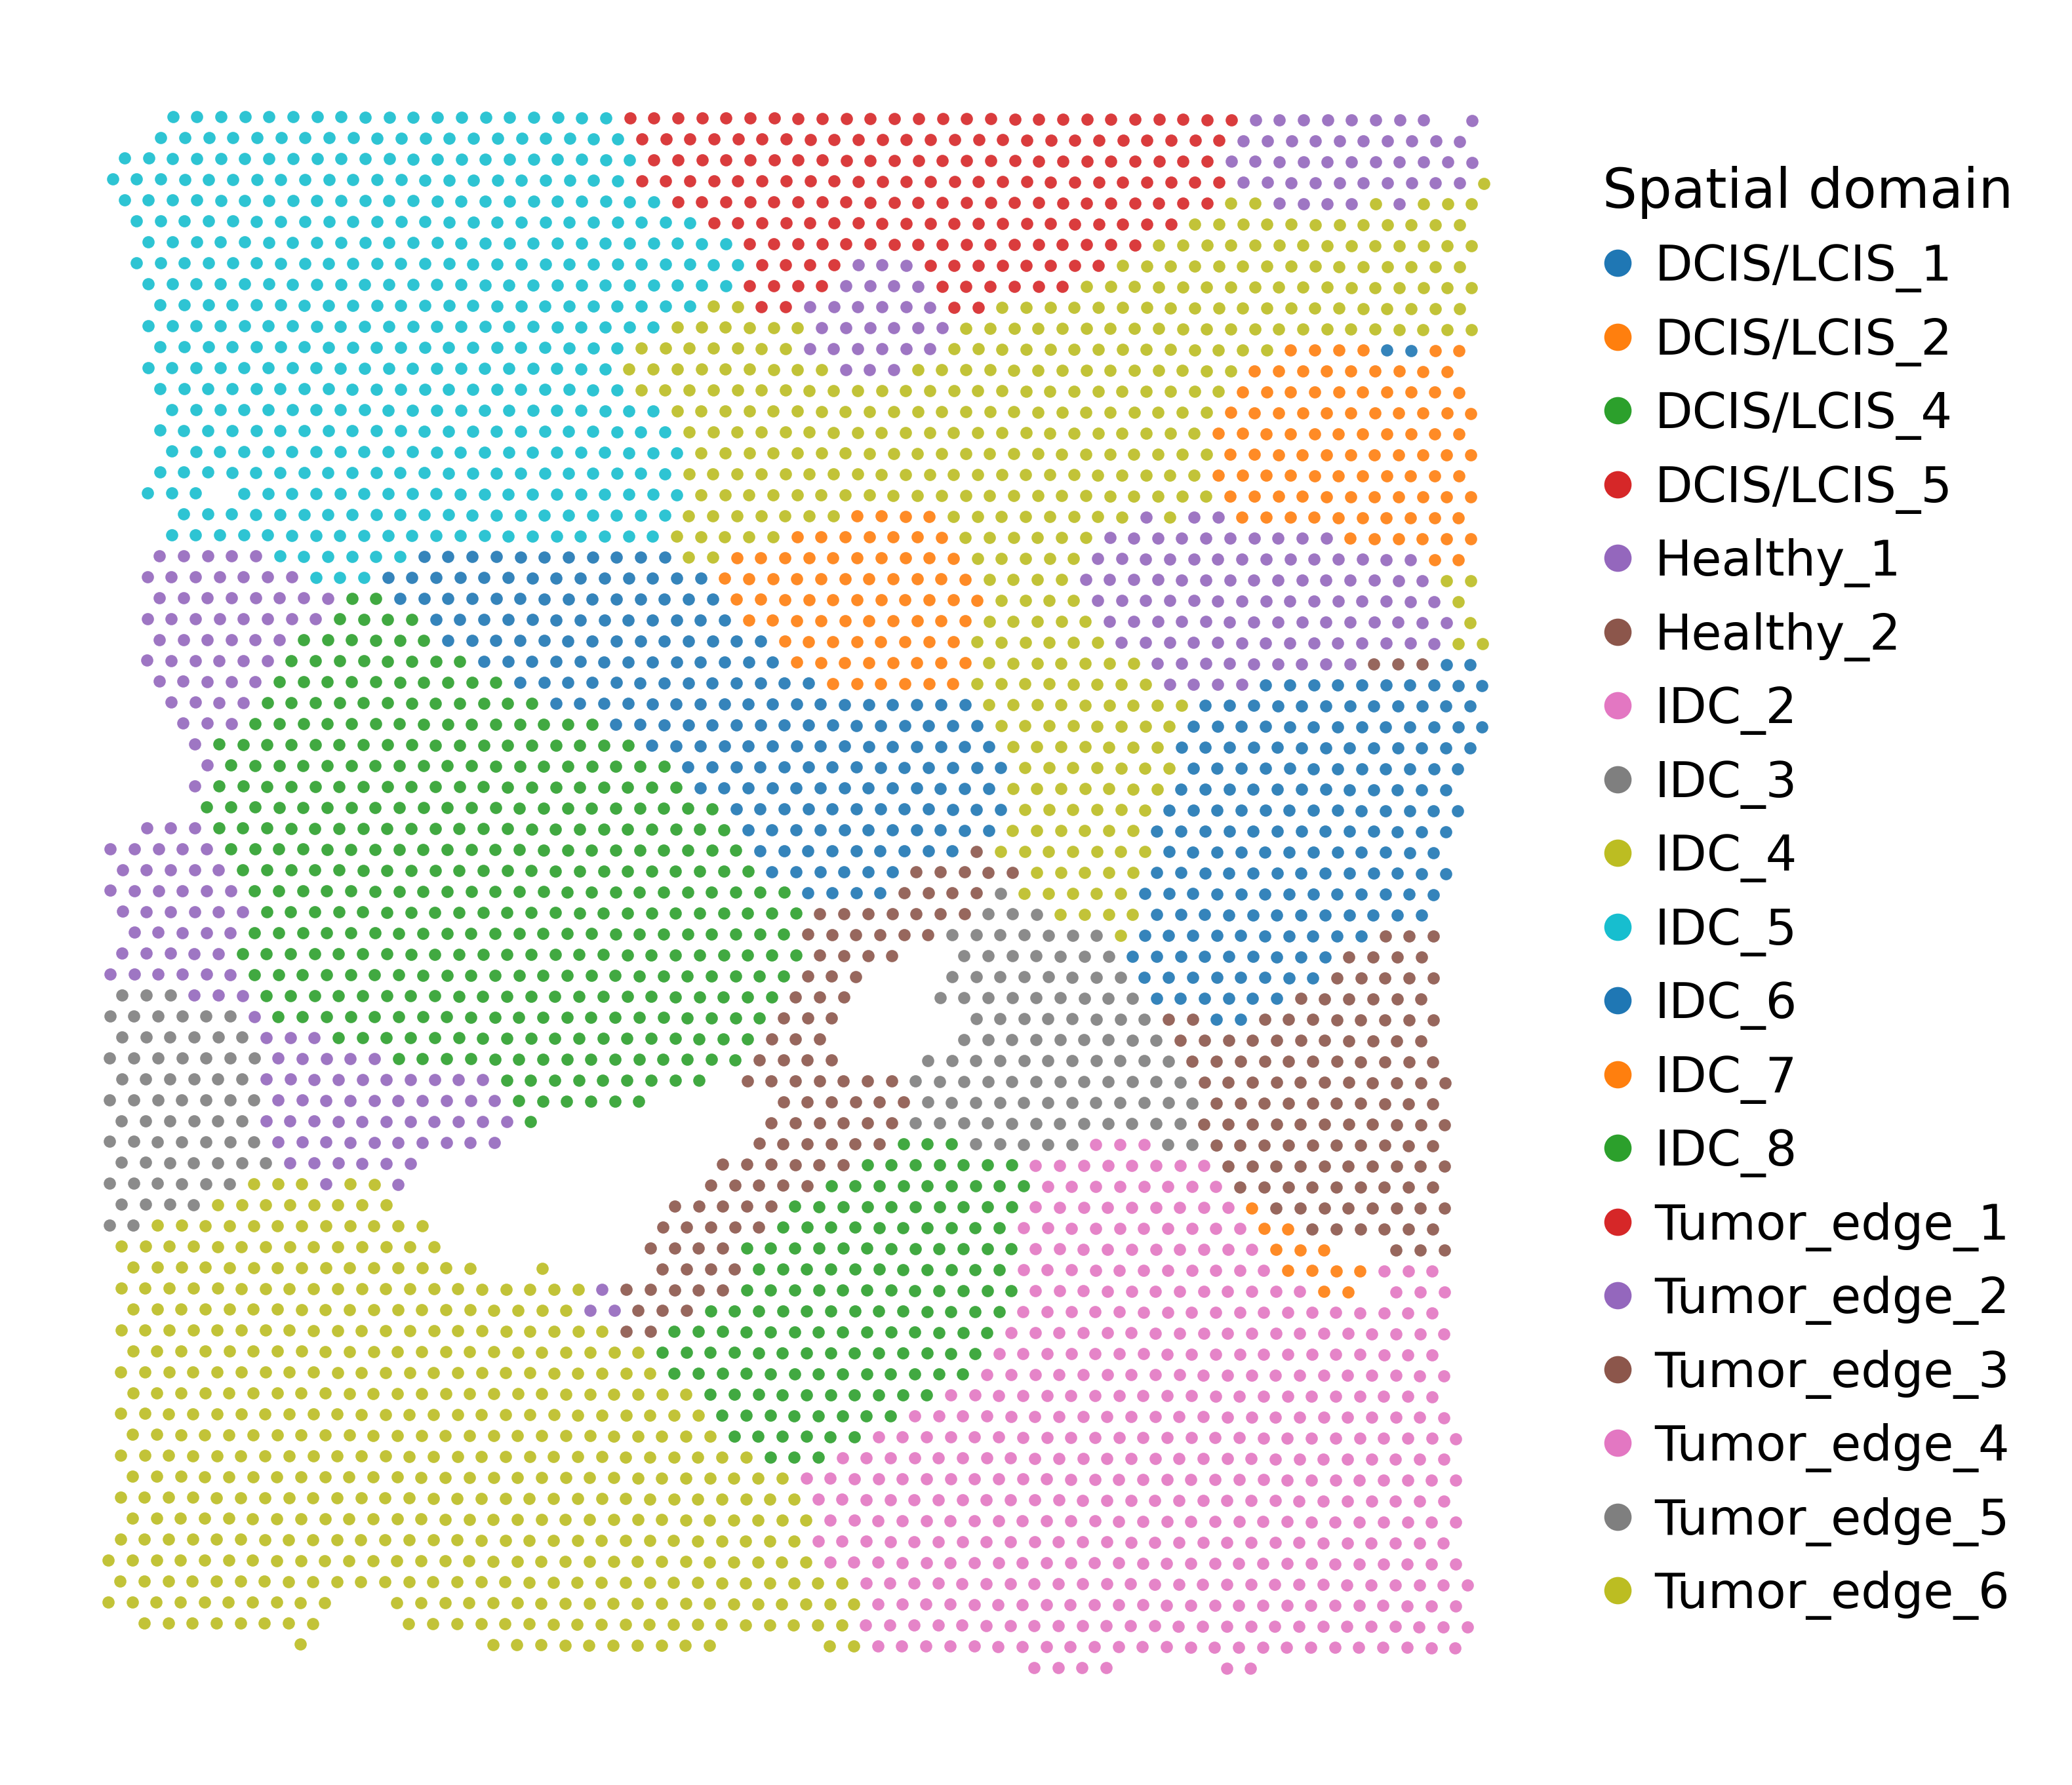

In [61]:
plot_2D(adata_test2, y_pred_decoded)

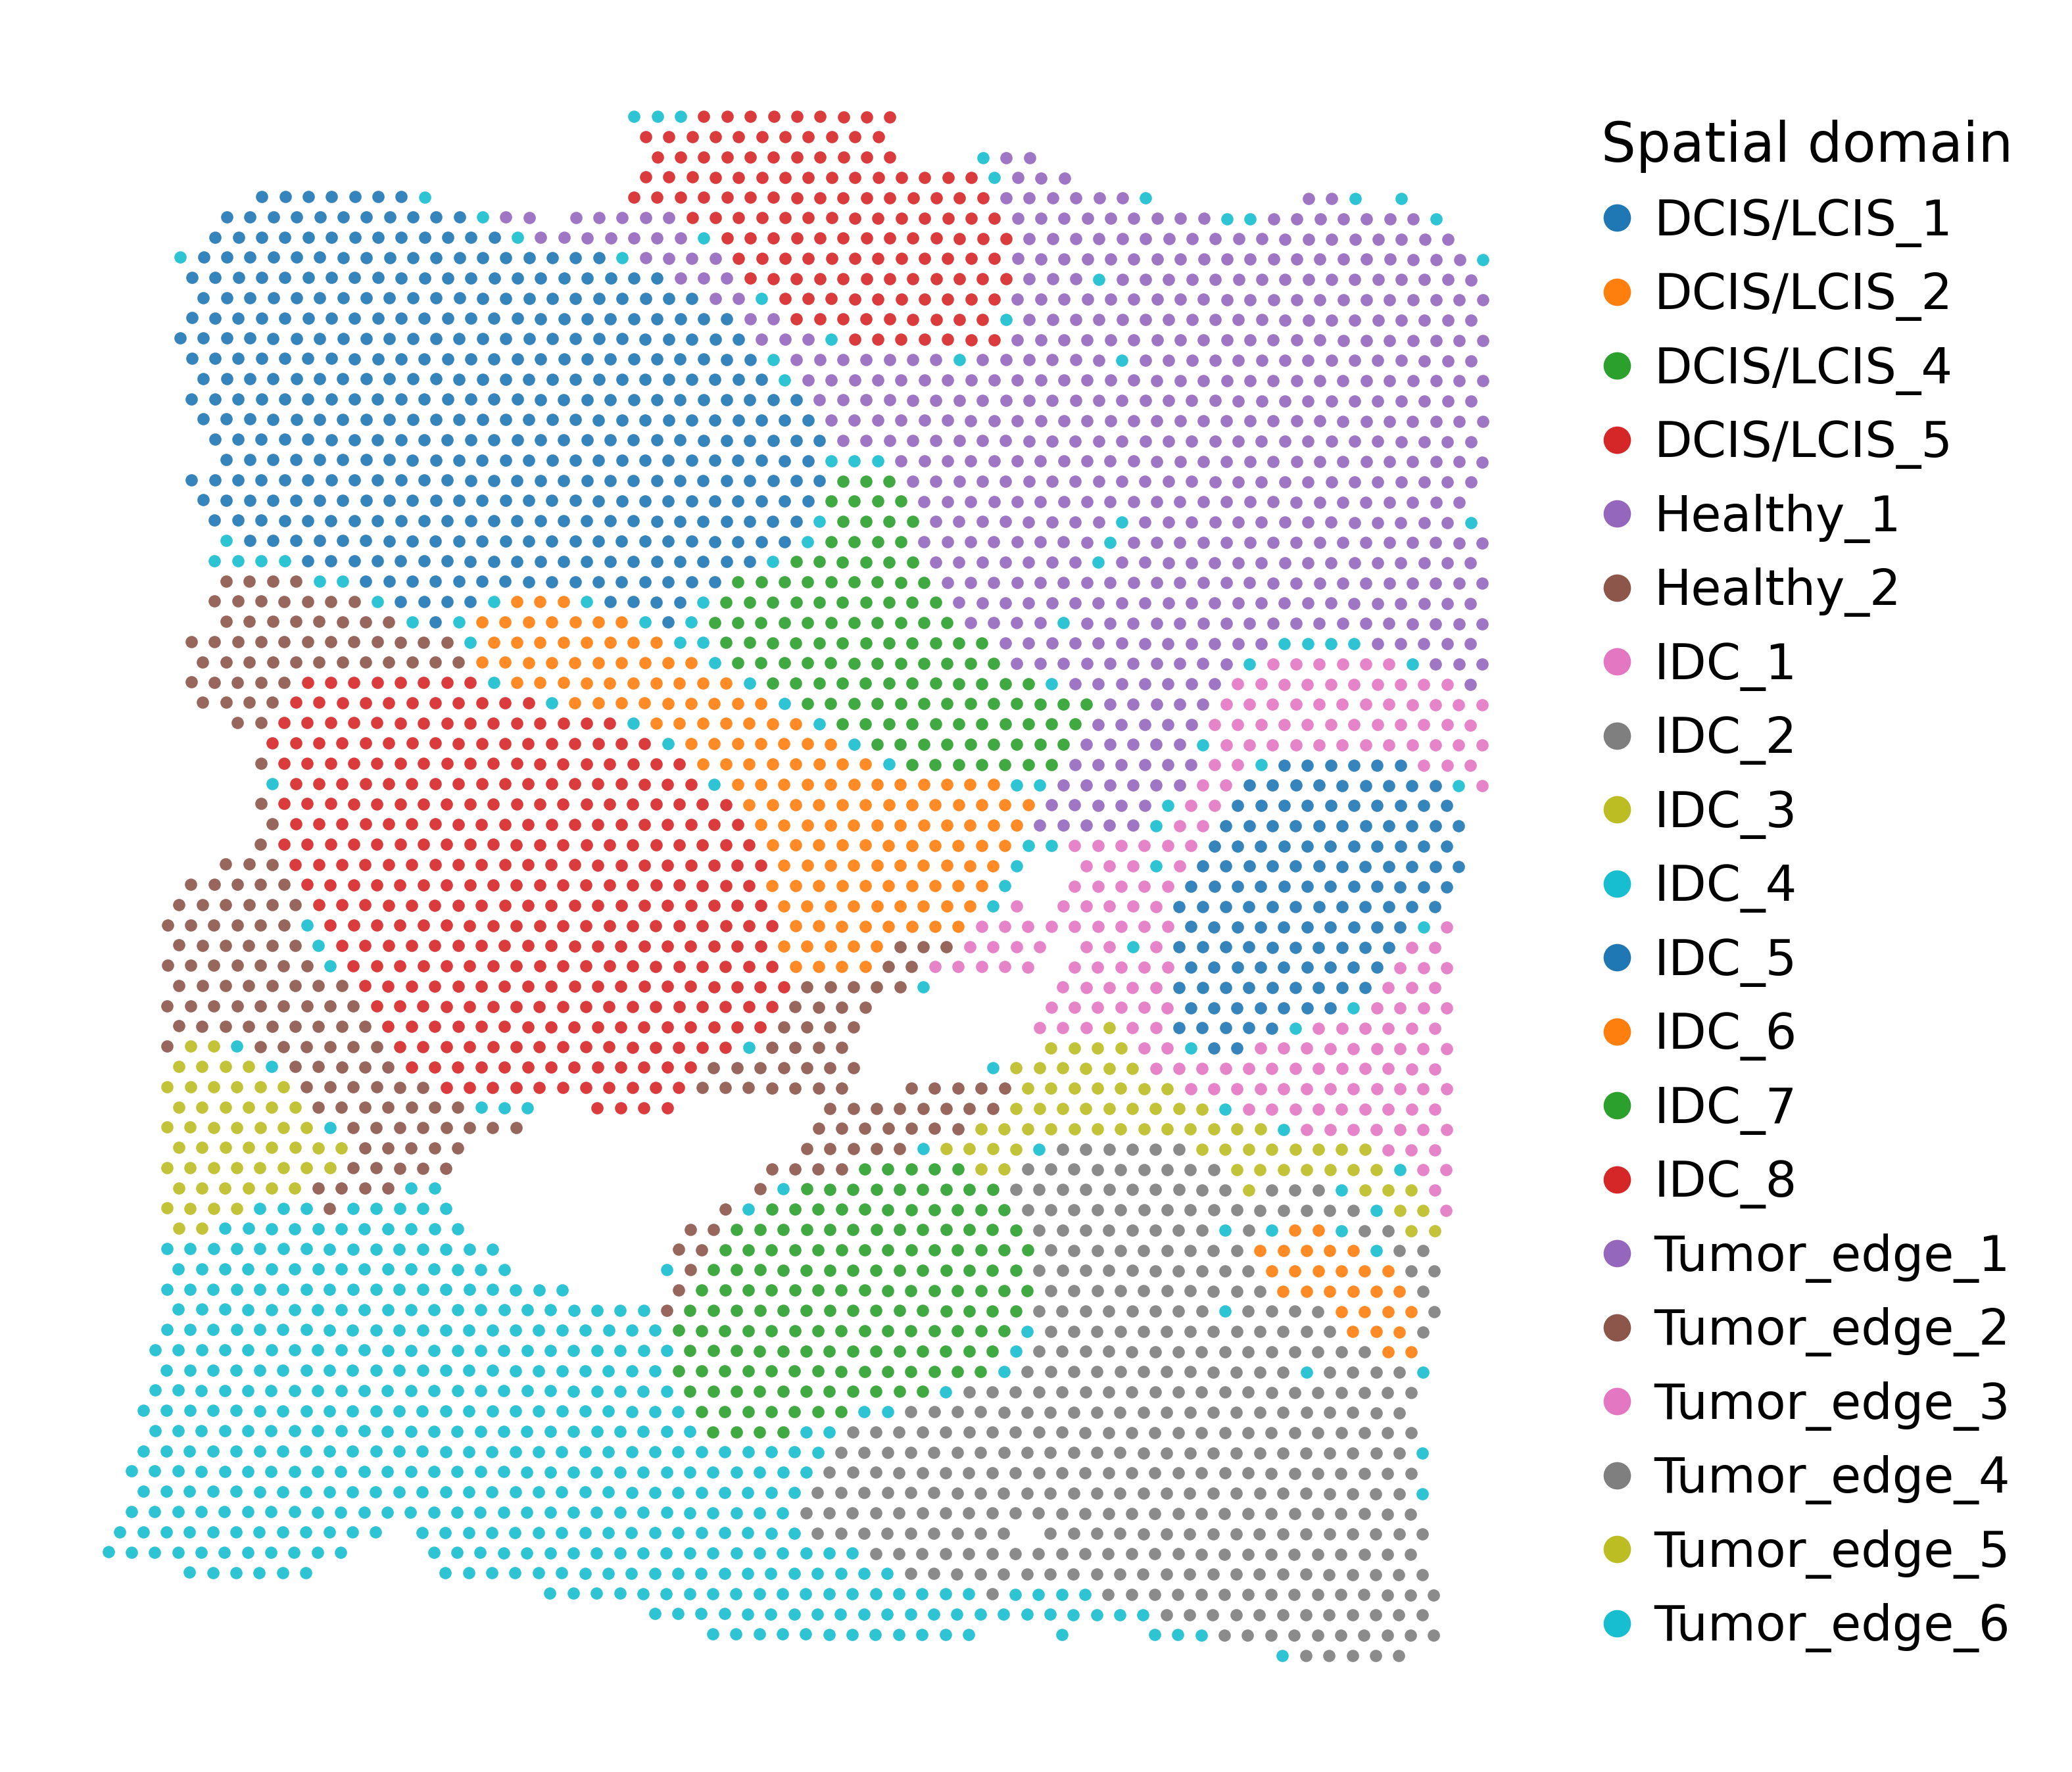

In [62]:
plot_2D(adata_train, adata_train.obs['niche'].values)

In [63]:
pd.DataFrame(emb_test_gpt).to_csv('emb_test_gpt_H'+str(n_hvg_genes)+'.csv')

In [64]:
pd.DataFrame(emb_train_gpt).to_csv('emb_train_gpt_H'+str(n_hvg_genes)+'.csv')

In [65]:
pd.DataFrame(y_pred_decoded).to_csv('y_pred_decoded_H'+str(n_hvg_genes)+'.csv',index=None)
